Create Tasmania bounding box 

<Axes: >

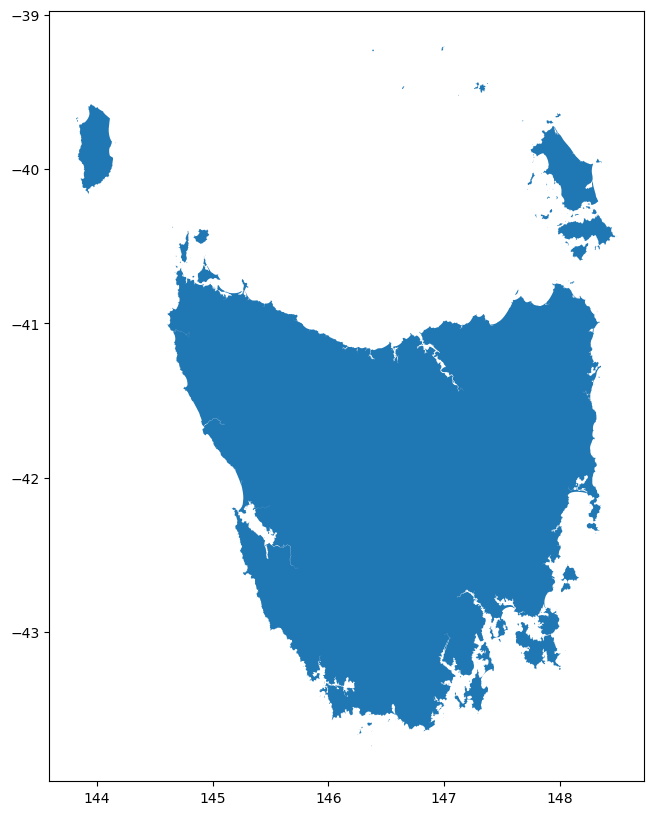

In [6]:
from pathlib import Path
import os
import geopandas as gpd
import geopandas as gpd
from shapely.geometry import box

inpath = Path(os.environ.get("AT3_DATA_DIR", "data")) #all original input files 
outpath = inpath / "Output_data" #all output files 
coastline_file_ABS_GDA2020 = inpath / "STE_2021_AUST_SHP_GDA2020/STE_2021_AUST_GDA2020.shp"
output_tas_bounding_box = outpath / "tasmania_bounding_box_GDA2020.shp"

gdf = gpd.read_file(str(coastline_file_ABS_GDA2020))

tas_bounding_box_GDA2020 = gdf[(gdf['STE_NAME21'] == 'Tasmania')] #EPSG:7844 is GDA2020 lat/long
tas_bounding_box_GDA2020.to_file(
    str(output_tas_bounding_box)
)
tas_bounding_box_GDA2020.plot(figsize=(10, 10))




Extract Mole Creek bounding box

<Axes: >

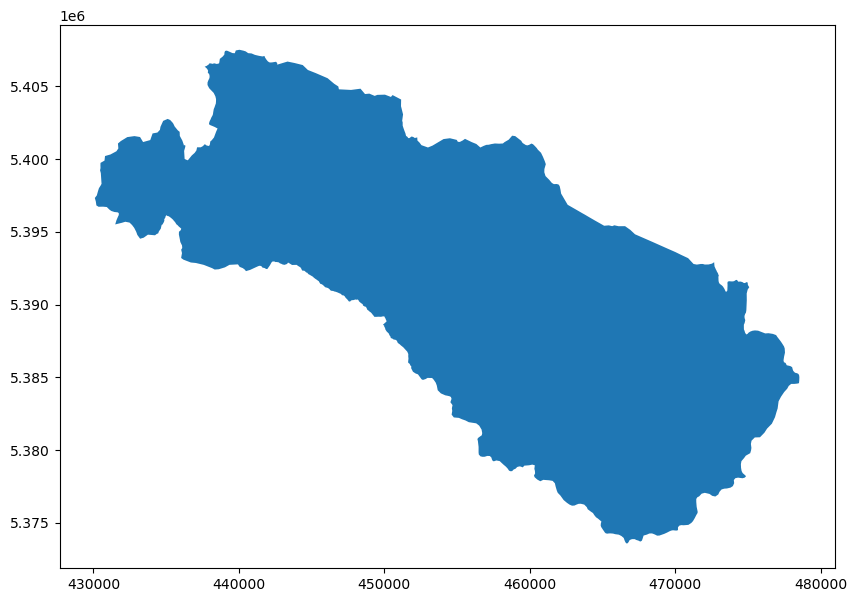

In [7]:
karst_atlas = inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp"
output_MC_bounding_box = outpath / "Mole_Creek_bounding_box_GDA94.shp"

gdf = gpd.read_file(str(karst_atlas))

MC_polygons = gdf[
    (gdf['KNAME'].str.contains('Mole Creek', na = False)) | 
    (gdf['KNAME'] == "Meander - Western Creek")
    ]

MC_mask_GDA94 = gpd.GeoSeries([MC_polygons.geometry.union_all()], crs = gdf.crs)
MC_mask_GDA94.to_file(
    str(output_MC_bounding_box)
)

MC_mask_GDA94.plot(figsize = (10, 10))